# Grupo 12 — Treino do Modelo (Landmarks Estáticos)
Este notebook carrega os landmarks extraídos pelo `Grupo12_1_static_melhorado.ipynb`,
treina um classificador MLP e avalia-o nos conjuntos de validação, teste interno e teste externo.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.neural_network import MLPClassifier

# Reprodutibilidade global
np.random.seed(42)

/home/tomas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Carregar e preparar os dados de treino

In [2]:
df = pd.read_csv("outputs/train_landmarks.csv")
print(f"Shape original: {df.shape}  # Esperado: (N, 85)")

# Verificação defensiva do número de features
assert df.shape[1] == 85, f"Esperadas 85 colunas (84 features + label), obtidas {df.shape[1]}"

# Remover classe 'nothing' (gesto indefinido, não relevante para classificação)
n_before = len(df)
df = df[df["label"] != "nothing"].copy()
print(f"Amostras removidas ('nothing'): {n_before - len(df)}")
print(f"Shape após remoção: {df.shape}")
print("\nDistribuição de classes:")
print(df["label"].value_counts().sort_index())

Shape original: (93480, 85)  # Esperado: (N, 85)
Amostras removidas ('nothing'): 0
Shape após remoção: (93480, 85)

Distribuição de classes:
label
A        3343
B        3257
C        3178
D        3611
E        3360
F        3935
G        3634
H        3493
I        3457
J        3642
K        3749
L        3600
M        2962
N        2604
O        3402
P        3158
Q        3222
R        3640
S        3622
T        3393
U        3555
V        3603
W        3519
X        3272
Y        3632
Z        3468
del      2005
space    2164
Name: count, dtype: int64


## 2. Divisão treino / validação / teste

In [3]:
X = df.drop(columns=["label"])
y = df["label"]

# 70% treino, 15% validação, 15% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Treino:     {len(X_train)} amostras")
print(f"Validação:  {len(X_val)} amostras")
print(f"Teste:      {len(X_test)} amostras")

Treino:     65436 amostras
Validação:  14022 amostras
Teste:      14022 amostras


## 3. Pré-processamento (LabelEncoder + StandardScaler)

In [4]:
# LabelEncoder: fit apenas no treino para evitar data leakage
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

# StandardScaler: fit apenas no treino
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Classes codificadas: {list(label_encoder.classes_)}")

Classes codificadas: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


## 4. Treino do modelo MLP

In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # Camadas maiores para captar detalhes subtis
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42,
    early_stopping=True,       # Evita overfitting
    validation_fraction=0.1,
    tol=1e-5,
    n_iter_no_change=20
)

mlp.fit(X_train_scaled, y_train_enc)
print(f"Treino concluído em {mlp.n_iter_} iterações.")

Treino concluído em 52 iterações.


## 5. Avaliação no conjunto de validação

In [6]:
val_pred = mlp.predict(X_val_scaled)
print("=== Validação ===")
print(f"Accuracy: {accuracy_score(y_val_enc, val_pred):.4f}")
print(f"Macro F1: {f1_score(y_val_enc, val_pred, average='macro'):.4f}")
print(classification_report(y_val_enc, val_pred, target_names=label_encoder.classes_))

=== Validação ===
Accuracy: 0.9840
Macro F1: 0.9827
              precision    recall  f1-score   support

           A       1.00      0.98      0.99       502
           B       0.99      0.99      0.99       488
           C       1.00      0.99      0.99       477
           D       0.99      0.99      0.99       542
           E       0.98      0.98      0.98       504
           F       0.99      0.98      0.99       590
           G       1.00      0.99      1.00       545
           H       1.00      0.99      0.99       524
           I       0.98      0.98      0.98       518
           J       0.99      0.99      0.99       546
           K       1.00      0.99      0.99       563
           L       0.99      1.00      0.99       540
           M       0.92      0.96      0.94       444
           N       0.94      0.94      0.94       390
           O       0.97      0.99      0.98       511
           P       0.99      0.99      0.99       473
           Q       0.99      

## 6. Avaliação no conjunto de teste interno

In [7]:
test_pred = mlp.predict(X_test_scaled)
print("=== Teste Interno ===")
print(f"Accuracy: {accuracy_score(y_test_enc, test_pred):.4f}")
print(f"Macro F1: {f1_score(y_test_enc, test_pred, average='macro'):.4f}")
print(classification_report(y_test_enc, test_pred, target_names=label_encoder.classes_))

=== Teste Interno ===
Accuracy: 0.9854
Macro F1: 0.9845
              precision    recall  f1-score   support

           A       0.98      0.97      0.98       501
           B       0.99      0.99      0.99       489
           C       0.99      0.99      0.99       476
           D       1.00      0.99      0.99       541
           E       0.99      0.99      0.99       504
           F       0.99      0.99      0.99       590
           G       0.99      0.99      0.99       545
           H       0.99      0.98      0.99       524
           I       0.97      0.99      0.98       519
           J       0.99      0.98      0.99       547
           K       0.99      0.99      0.99       562
           L       1.00      0.99      0.99       540
           M       0.93      0.98      0.95       445
           N       0.95      0.95      0.95       391
           O       0.97      0.99      0.98       510
           P       0.99      0.98      0.99       474
           Q       0.99  

## 7. Matriz de confusão — Teste Interno

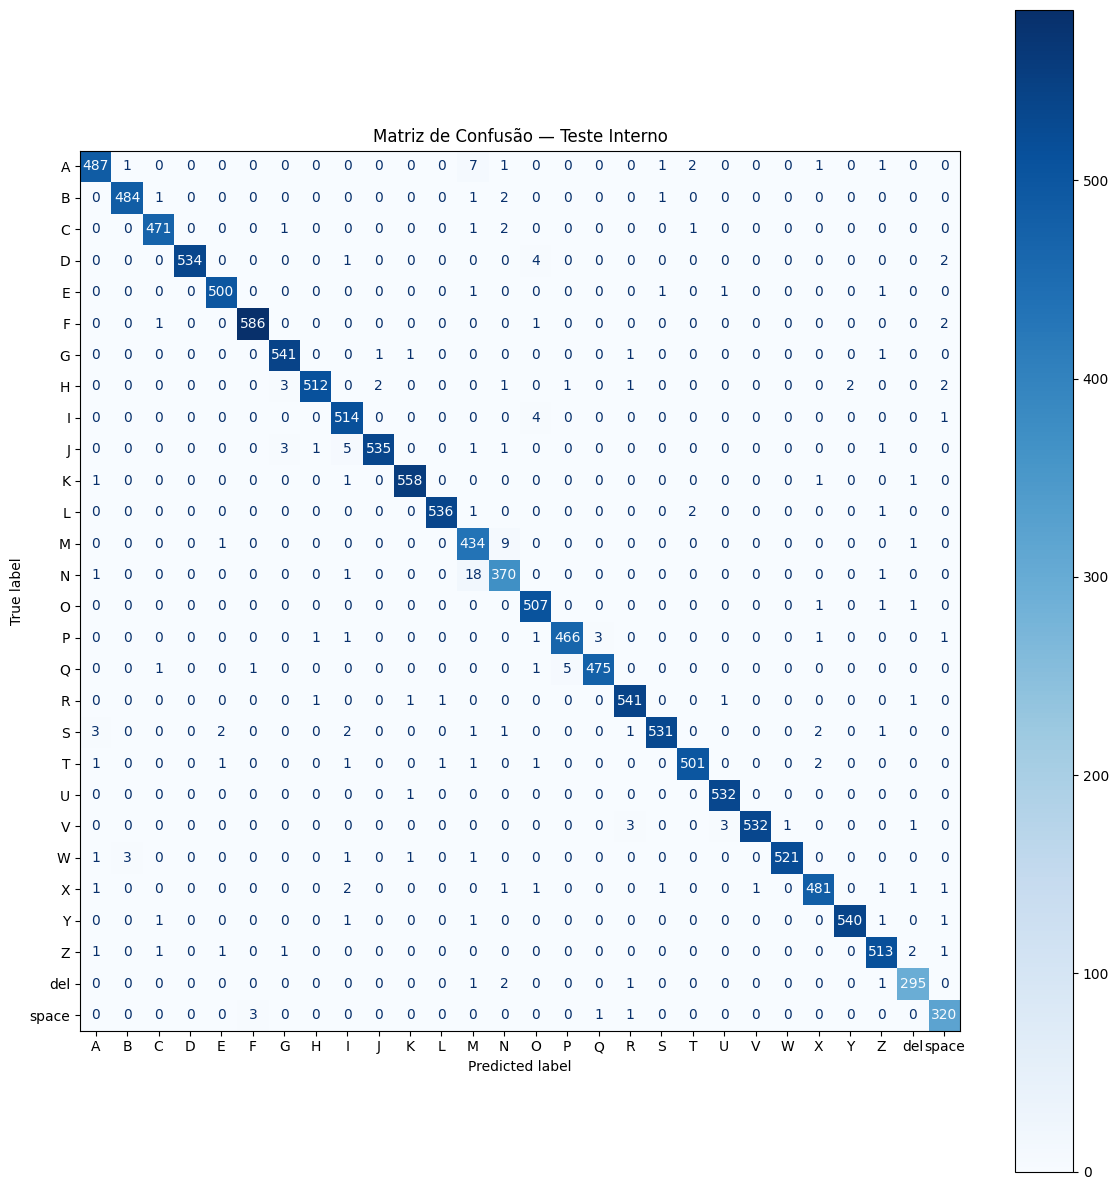

In [8]:
cm = confusion_matrix(y_test_enc, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Matriz de Confusão — Teste Interno")
plt.tight_layout()
plt.show()

## 8. Guardar o modelo

In [9]:
os.makedirs("models", exist_ok=True)
joblib.dump(mlp,           "models/mlp_asl_landmarks.joblib")
joblib.dump(scaler,        "models/scaler_asl_landmarks.joblib")
joblib.dump(label_encoder, "models/label_encoder_asl_landmarks.joblib")
print("Modelo, scaler e label encoder guardados em 'models/'.")

Modelo, scaler e label encoder guardados em 'models/'.


## 9. Avaliação no conjunto de teste externo (`test_landmarks.csv`)

In [10]:
df_ext = pd.read_csv("outputs/test_landmarks.csv")

# Filtrar apenas labels conhecidas pelo modelo (exclui 'nothing' e outras desconhecidas)
n_before_ext = len(df_ext)
df_ext = df_ext[df_ext["label"].isin(label_encoder.classes_)].copy()
n_removed_ext = n_before_ext - len(df_ext)
if n_removed_ext > 0:
    print(f"[AVISO] {n_removed_ext} amostras removidas por terem labels desconhecidas (ex: 'nothing').")

X_ext = df_ext.drop(columns=["label"])
y_ext = df_ext["label"]

y_ext_enc  = label_encoder.transform(y_ext)
X_ext_scaled = scaler.transform(X_ext)

ext_pred = mlp.predict(X_ext_scaled)

print("=== Teste Externo ===")
print(f"Accuracy: {accuracy_score(y_ext_enc, ext_pred):.4f}")
print(f"Macro F1: {f1_score(y_ext_enc, ext_pred, average='macro'):.4f}")
print(classification_report(y_ext_enc, ext_pred, target_names=label_encoder.classes_))

=== Teste Externo ===
Accuracy: 0.8524
Macro F1: 0.8361
              precision    recall  f1-score   support

           A       0.93      0.82      0.87        76
           B       0.95      1.00      0.98        99
           C       0.78      0.59      0.67        83
           D       0.82      0.92      0.87        99
           E       0.87      0.94      0.90        82
           F       1.00      0.99      0.99       100
           G       0.98      0.86      0.91        99
           H       0.95      1.00      0.98        98
           I       0.89      0.98      0.93        90
           J       0.96      0.94      0.95        71
           K       0.97      0.94      0.95        97
           L       0.92      0.98      0.95       100
           M       0.52      0.74      0.61        62
           N       0.62      0.32      0.42        65
           O       0.73      0.71      0.72        77
           P       0.88      1.00      0.93        98
           Q       1.00  

## 10. Matriz de confusão — Teste Externo

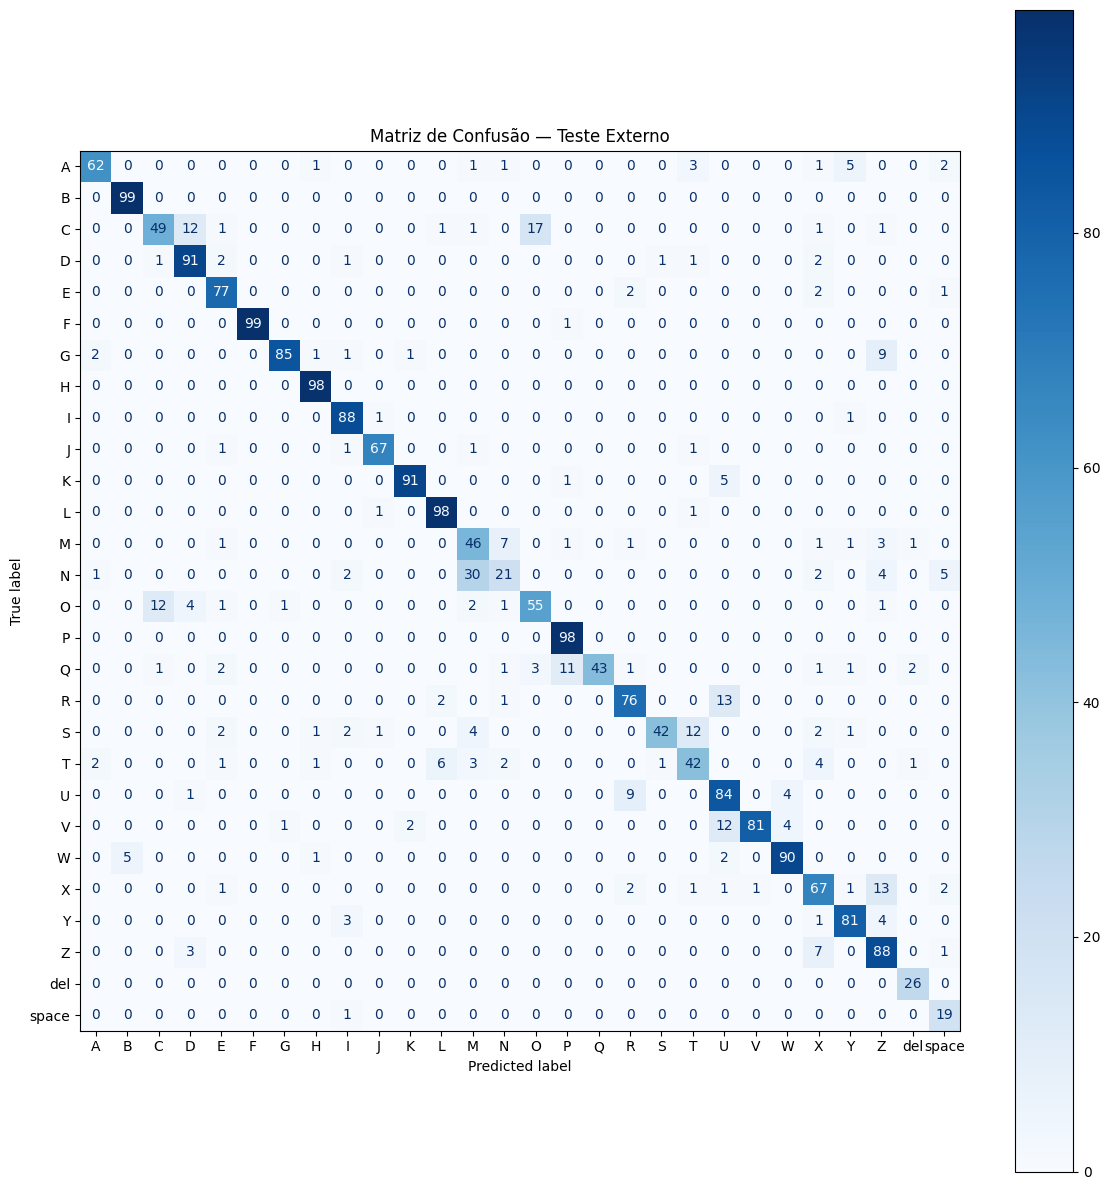

In [11]:
cm_ext = confusion_matrix(y_ext_enc, ext_pred)
disp_ext = ConfusionMatrixDisplay(confusion_matrix=cm_ext, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 12))
disp_ext.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Matriz de Confusão — Teste Externo")
plt.tight_layout()
plt.show()

## 11. Resumo comparativo val / teste interno / teste externo

In [12]:
summary = pd.DataFrame({
    "Conjunto":  ["Validação", "Teste Interno", "Teste Externo"],
    "Accuracy":  [
        accuracy_score(y_val_enc,  val_pred),
        accuracy_score(y_test_enc, test_pred),
        accuracy_score(y_ext_enc,  ext_pred)
    ],
    "Macro F1":  [
        f1_score(y_val_enc,  val_pred,  average='macro'),
        f1_score(y_test_enc, test_pred, average='macro'),
        f1_score(y_ext_enc,  ext_pred,  average='macro')
    ]
})
summary = summary.set_index("Conjunto").round(4)
print(summary.to_string())

               Accuracy  Macro F1
Conjunto                         
Validação        0.9840    0.9827
Teste Interno    0.9854    0.9845
Teste Externo    0.8524    0.8361
